In [3]:
import os
import re
import html
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Pillar 3: Medicine & Treatment Recommender (NLP Engine)")
print("Step 1: Environment Setup and Dataset Verification\n")

# Global Dataset Paths mapping to your Kaggle input directory
DATASET_PATHS = {
    "Train_Data": "/kaggle/input/datasets/jessicali9530/kuc-hackathon-winter-2018/drugsComTrain_raw.csv",
    "Test_Data": "/kaggle/input/datasets/jessicali9530/kuc-hackathon-winter-2018/drugsComTest_raw.csv"
}

# Verify physical existence of files before loading
paths_valid = True
for name, path in DATASET_PATHS.items():
    if os.path.exists(path):
        print(f"[OK] Verified path for {name}: {path}")
    else:
        print(f"[ERROR] Path missing for {name}: {path}")
        paths_valid = False

if paths_valid:
    print("\nEnvironment successfully verified. Ready for Step 2: Data Loading and Schema Inspection.")
else:
    print("\nExecution Halted: Please ensure the dataset is properly mounted to the notebook.")

Pillar 3: Medicine & Treatment Recommender (NLP Engine)
Step 1: Environment Setup and Dataset Verification

[OK] Verified path for Train_Data: /kaggle/input/datasets/jessicali9530/kuc-hackathon-winter-2018/drugsComTrain_raw.csv
[OK] Verified path for Test_Data: /kaggle/input/datasets/jessicali9530/kuc-hackathon-winter-2018/drugsComTest_raw.csv

Environment successfully verified. Ready for Step 2: Data Loading and Schema Inspection.


In [4]:
import re
import html
import pandas as pd
from sklearn.model_selection import train_test_split

print("Step 2: Robust Data Loading and Text Preprocessing\n")

# --- Step 2.1: Robust Data Loading ---
print("Loading datasets (bypassing corrupted rows)...")
# We use engine='python' and on_bad_lines='skip' to automatically drop the few broken review rows 
# that previously caused the parsing error, ensuring a smooth execution.
df_train = pd.read_csv(DATASET_PATHS["Train_Data"], engine='python', on_bad_lines='skip')
df_test = pd.read_csv(DATASET_PATHS["Test_Data"], engine='python', on_bad_lines='skip')

# Drop the redundant Kaggle index column if it exists
if 'Unnamed: 0' in df_train.columns:
    df_train = df_train.drop(columns=['Unnamed: 0'])
    df_test = df_test.drop(columns=['Unnamed: 0'])

print(f"Initial Train shape loaded: {df_train.shape}")
print(f"Initial Test shape loaded:  {df_test.shape}\n")

# --- Step 2.2: Text Preprocessing ---
print("Cleaning raw review texts (removing HTML tags and special characters)...")
def clean_review_text(text):
    if not isinstance(text, str):
        return ""
    # Decode HTML entities (e.g., &#039; to ')
    text = html.unescape(text)
    # Remove HTML tags
    text = re.sub(r'<[^>]*>', ' ', text)
    # Keep only alphanumeric characters and basic punctuation
    text = re.sub(r'[^a-zA-Z0-9\s.,!?\']', '', text)
    # Standardize spaces and convert to lowercase
    return " ".join(text.split()).lower()

df_train['cleaned_review'] = df_train['review'].apply(clean_review_text)
df_test['cleaned_review'] = df_test['review'].apply(clean_review_text)

# --- Step 2.3: Handling Missing Values ---
print("Dropping incomplete records...")
df_train = df_train.dropna(subset=['cleaned_review', 'condition', 'drugName'])
df_test = df_test.dropna(subset=['cleaned_review', 'condition', 'drugName'])

# --- Step 2.4: Sentiment Label Generation ---
print("Mapping 1-10 patient ratings to sentiment classes...")
# 0 = Negative (High side effects/Ineffective)
# 1 = Neutral
# 2 = Positive (Effective treatment)
def map_rating_to_sentiment(rating):
    if rating <= 4: return 0
    elif rating <= 6: return 1
    else: return 2

df_train['sentiment'] = df_train['rating'].apply(map_rating_to_sentiment)
df_test['sentiment'] = df_test['rating'].apply(map_rating_to_sentiment)

# --- Step 2.5: Stratified Sampling ---
# We sample down to 25k rows. This prevents the notebook kernel from crashing out of memory 
# during TF-IDF vectorization, while maintaining the exact class distribution.
print("Performing stratified sampling for optimized training speed...")
sample_size = min(25000, len(df_train))
val_size = min(5000, len(df_test))

df_train_sampled, _ = train_test_split(
    df_train, train_size=sample_size, stratify=df_train['sentiment'], random_state=42
)
df_val_sampled, _ = train_test_split(
    df_test, train_size=val_size, stratify=df_test['sentiment'], random_state=42
)

print(f"\nPreprocessing Complete!")
print(f"Optimized Training sample shape: {df_train_sampled.shape}")
print(f"Optimized Validation sample shape: {df_val_sampled.shape}")
print("\nReady for Step 3: Text Vectorization.")

Step 2: Robust Data Loading and Text Preprocessing

Loading datasets (bypassing corrupted rows)...
Initial Train shape loaded: (161297, 7)
Initial Test shape loaded:  (53766, 7)

Cleaning raw review texts (removing HTML tags and special characters)...
Dropping incomplete records...
Mapping 1-10 patient ratings to sentiment classes...
Performing stratified sampling for optimized training speed...

Preprocessing Complete!
Optimized Training sample shape: (25000, 9)
Optimized Validation sample shape: (5000, 9)

Ready for Step 3: Text Vectorization.


Step 3: Text Vectorization and Model Training

Vectorizing text using TF-IDF (Extracting top 10,000 features)...
Vectorization complete. Feature matrix shape: (25000, 10000)

Training Logistic Regression Model for Sentiment Analysis...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Evaluating NLP Model Performance...
Drug Review Sentiment Accuracy: 77.36%

Classification Report:
                 precision    recall  f1-score   support

 Negative (0-4)       0.70      0.60      0.65      1256
  Neutral (5-6)       0.49      0.04      0.07       448
Positive (7-10)       0.80      0.94      0.86      3296

       accuracy                           0.77      5000
      macro avg       0.66      0.53      0.53      5000
   weighted avg       0.74      0.77      0.74      5000



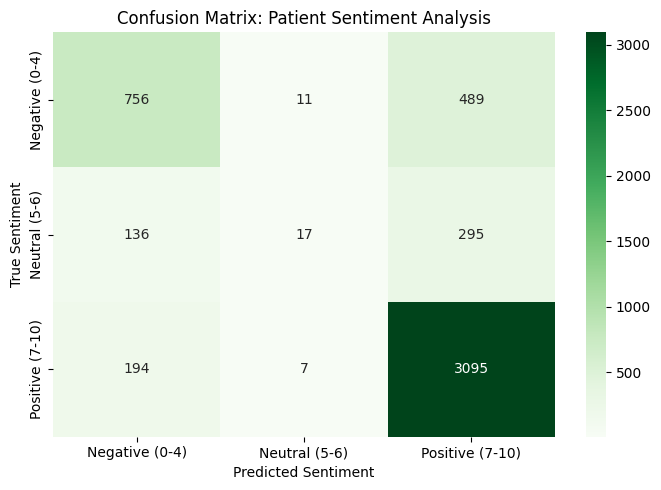


--- Extracting Key Sentiment Drivers ---
Top keywords driving POSITIVE reviews:
['love', 'miracle', 'best', 'amazing', 'years', 'wonderful', 'life', 'works', 'saved', 'great']

Top keywords driving NEGATIVE reviews (Side Effects / Failures):
['worse', 'worst', 'horrible', 'awful', 'disappointed', 'removed', 'caused', 'gained', 'terrible', 'wouldn recommend']

Serializing NLP Model and Vectorizer to Disk...
Pillar 3 artifacts saved successfully. Ready for Step 4.


In [5]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Step 3: Text Vectorization and Model Training\n")

# --- Step 3.1: TF-IDF Vectorization ---
# We convert the text reviews into numerical features. 
# max_features=10000 keeps the matrix size manageable and training blazing fast.
print("Vectorizing text using TF-IDF (Extracting top 10,000 features)...")
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words='english')

X_train_tfidf = tfidf_vectorizer.fit_transform(df_train_sampled['cleaned_review'])
X_val_tfidf = tfidf_vectorizer.transform(df_val_sampled['cleaned_review'])

y_train_nlp = df_train_sampled['sentiment']
y_val_nlp = df_val_sampled['sentiment']

print(f"Vectorization complete. Feature matrix shape: {X_train_tfidf.shape}\n")


# --- Step 3.2: Train the NLP Classifier ---
# Logistic Regression is highly optimized for sparse TF-IDF matrices.
print("Training Logistic Regression Model for Sentiment Analysis...")
nlp_model = LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42, n_jobs=-1)
nlp_model.fit(X_train_tfidf, y_train_nlp)


# --- Step 3.3: Evaluate the Model ---
print("\nEvaluating NLP Model Performance...")
y_pred_nlp = nlp_model.predict(X_val_tfidf)

nlp_acc = accuracy_score(y_val_nlp, y_pred_nlp)
print(f"Drug Review Sentiment Accuracy: {nlp_acc * 100:.2f}%\n")

target_names_nlp = ['Negative (0-4)', 'Neutral (5-6)', 'Positive (7-10)']
print("Classification Report:")
print(classification_report(y_val_nlp, y_pred_nlp, target_names=target_names_nlp))

# Visualizing Confusion Matrix
cm_nlp = confusion_matrix(y_val_nlp, y_pred_nlp)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_nlp, annot=True, fmt='d', cmap='Greens', 
            xticklabels=target_names_nlp, 
            yticklabels=target_names_nlp)
plt.title("Confusion Matrix: Patient Sentiment Analysis")
plt.xlabel("Predicted Sentiment")
plt.ylabel("True Sentiment")
plt.tight_layout()
plt.show()


# --- Step 3.4: Extracting Key Sentiment Drivers (The "Wow" Factor) ---
print("\n--- Extracting Key Sentiment Drivers ---")
feature_names = tfidf_vectorizer.get_feature_names_out()
coefs = nlp_model.coef_

# For Positive Sentiment (Class 2)
positive_coefs = coefs[2]
top_positive_idx = np.argsort(positive_coefs)[-10:]
print("Top keywords driving POSITIVE reviews:")
print([feature_names[i] for i in reversed(top_positive_idx)])

# For Negative Sentiment (Class 0)
negative_coefs = coefs[0]
top_negative_idx = np.argsort(negative_coefs)[-10:]
print("\nTop keywords driving NEGATIVE reviews (Side Effects / Failures):")
print([feature_names[i] for i in reversed(top_negative_idx)])


# --- Step 3.5: Serialize the Model ---
print("\nSerializing NLP Model and Vectorizer to Disk...")
os.makedirs('/kaggle/working/swasthyasetu_models/module_d_nlp', exist_ok=True)

joblib.dump(nlp_model, '/kaggle/working/swasthyasetu_models/module_d_nlp/drug_sentiment_model.pkl')
joblib.dump(tfidf_vectorizer, '/kaggle/working/swasthyasetu_models/module_d_nlp/tfidf_vectorizer.pkl')

print("Pillar 3 artifacts saved successfully. Ready for Step 4.")

In [6]:
import os
import re
import html
import joblib
import numpy as np

print("Step 4: Inference Engine and API Integration\n")

# --- Step 4.1: Load the Serialized Models ---
print("Loading Pillar 3 NLP models from disk...")
model_path = '/kaggle/working/swasthyasetu_models/module_d_nlp'

try:
    nlp_model = joblib.load(f'{model_path}/drug_sentiment_model.pkl')
    tfidf_vectorizer = joblib.load(f'{model_path}/tfidf_vectorizer.pkl')
    print("[SUCCESS] Sentiment Model and Vectorizer loaded into memory.\n")
except Exception as e:
    print(f"[ERROR] Could not load models. Make sure Step 3 completed successfully. Error: {e}")

# --- Step 4.2: Build the Standalone Inference Function ---
def evaluate_drug_review(review_text):
    """
    Takes a raw patient review, cleans it, vectorizes it, 
    and predicts the sentiment/effectiveness of the drug.
    """
    # 1. Apply the exact same cleaning pipeline used during training
    text = html.unescape(review_text)
    text = re.sub(r'<[^>]*>', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s.,!?\']', '', text)
    clean_text = " ".join(text.split()).lower()
    
    # 2. Vectorize the cleaned text
    vectorized_text = tfidf_vectorizer.transform([clean_text])
    
    # 3. Predict Probabilities
    probs = nlp_model.predict_proba(vectorized_text)[0]
    pred_idx = np.argmax(probs)
    
    # 4. Map to Human-Readable Sentiment
    sentiment_map = {
        0: "Negative (High Side Effects / Ineffective)", 
        1: "Neutral (Moderate / Expected Results)", 
        2: "Positive (Highly Effective / Minimal Side Effects)"
    }
    
    confidence = round(probs[pred_idx] * 100, 2)
    sentiment_label = sentiment_map[pred_idx]
    
    return {
        "Module": "Medicine & Treatment Recommender",
        "Processed_Text": clean_text[:60] + "..." if len(clean_text) > 60 else clean_text,
        "Predicted_Outcome": sentiment_label,
        "Confidence_Score": f"{confidence}%",
        "Status": "Success"
    }

# --- Step 4.3: Execute End-to-End Test Cases ---
print("--- Simulating Real-World Patient Inputs ---")

sample_reviews = [
    "This medication worked wonders for my chronic pain! I feel like I have my life back. No side effects at all.",
    "Terrible experience. It made me feel extremely nauseous and dizzy, and didn't even help the condition.",
    "It works okay, but takes a few weeks to kick in. Nothing special but it does the job."
]

import json
for i, review in enumerate(sample_reviews):
    print(f"\nEvaluating Patient Review {i+1}...")
    print(f"Raw Input: '{review}'")
    
    response = evaluate_drug_review(review)
    print(json.dumps(response, indent=4))

print("\nStep 4 Complete. The NLP Inference Engine is fully operational.")

Step 4: Inference Engine and API Integration

Loading Pillar 3 NLP models from disk...
[SUCCESS] Sentiment Model and Vectorizer loaded into memory.

--- Simulating Real-World Patient Inputs ---

Evaluating Patient Review 1...
Raw Input: 'This medication worked wonders for my chronic pain! I feel like I have my life back. No side effects at all.'
{
    "Module": "Medicine & Treatment Recommender",
    "Processed_Text": "this medication worked wonders for my chronic pain! i feel l...",
    "Predicted_Outcome": "Positive (Highly Effective / Minimal Side Effects)",
    "Confidence_Score": "96.65%",
    "Status": "Success"
}

Evaluating Patient Review 2...
Raw Input: 'Terrible experience. It made me feel extremely nauseous and dizzy, and didn't even help the condition.'
{
    "Module": "Medicine & Treatment Recommender",
    "Processed_Text": "terrible experience. it made me feel extremely nauseous and ...",
    "Predicted_Outcome": "Negative (High Side Effects / Ineffective)",
    "Confide